In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [30]:
df = sns.load_dataset("tips")
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


## Problem statement :
We have to predict the tip  based on the six given features using linear regression

### Data Preprocessing

In [31]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [32]:
df.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


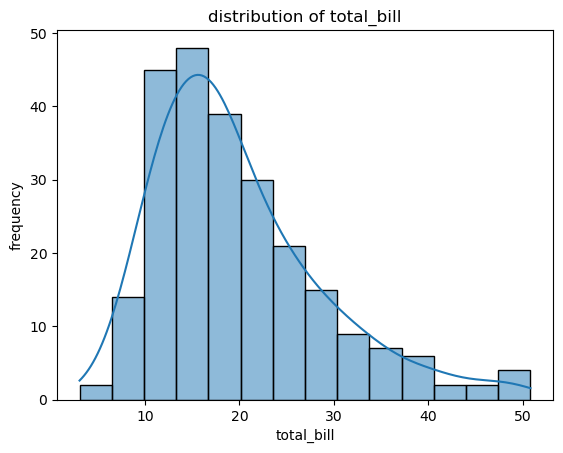

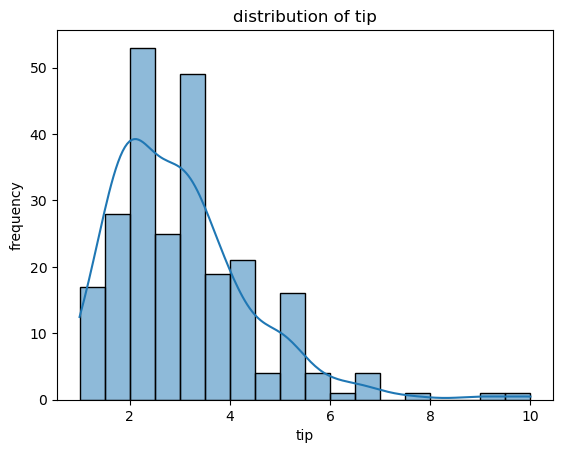

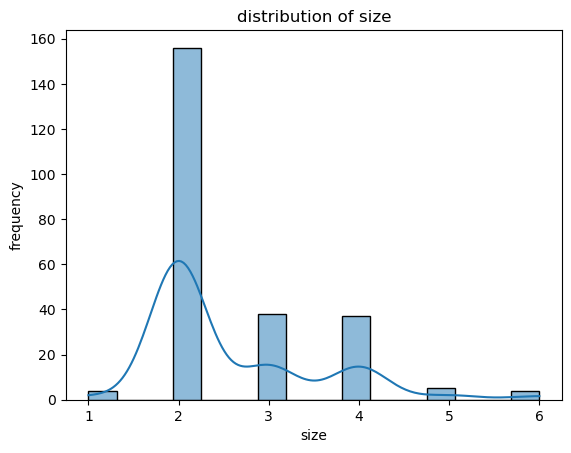

In [33]:
numeric_cols = df.select_dtypes(np.number)
for col in numeric_cols :
    plt.title(f"distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("frequency")
    sns.histplot(df[col],kde=True)
    plt.show()

- here size is the categorical column so convert its dtype
- is normal distribution is necessary for linear regression

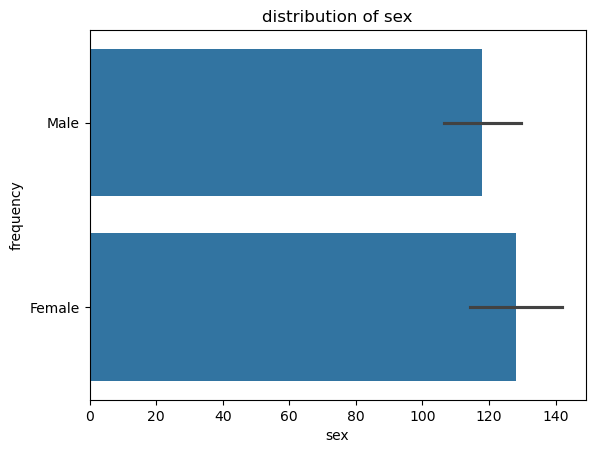

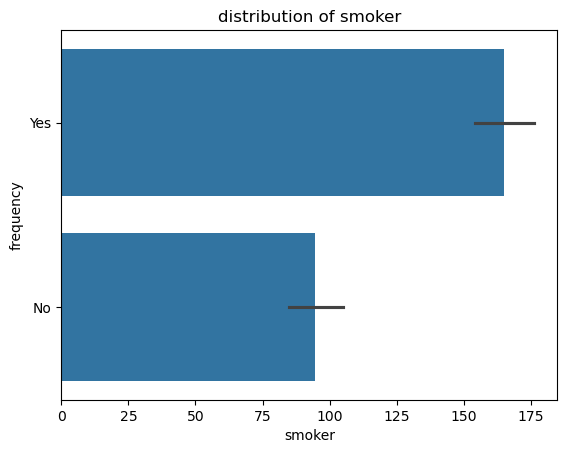

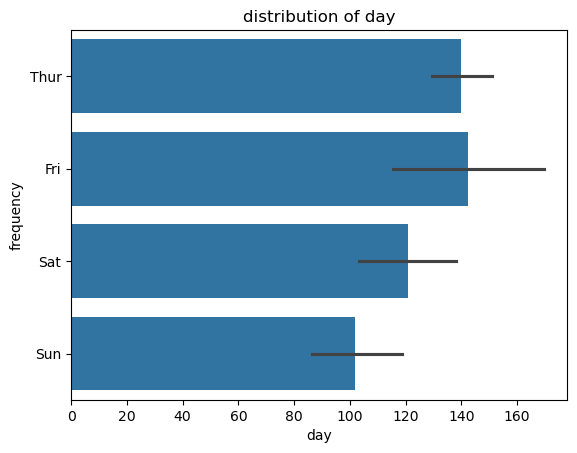

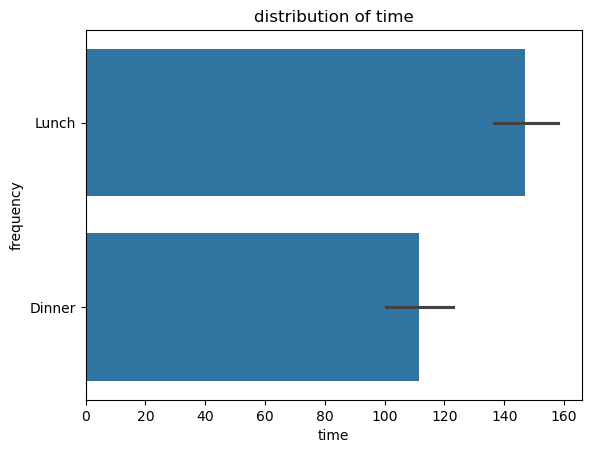

In [34]:
cat_cols = ["sex","smoker","day","time"]
for col in cat_cols :
    plt.title(f"distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("frequency")
    sns.barplot(df[col])
    plt.show()

<Axes: xlabel='total_bill', ylabel='tip'>

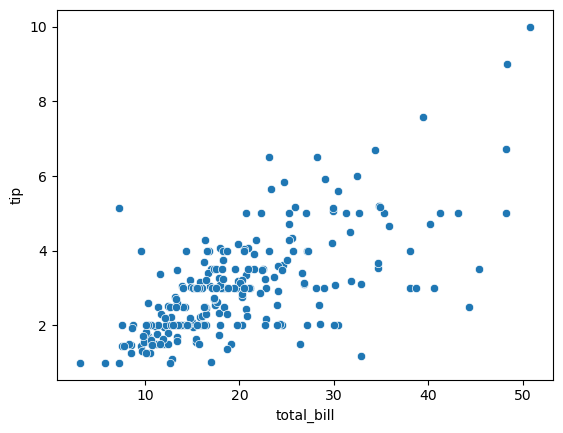

In [35]:
sns.scatterplot(x=df["total_bill"],y=df["tip"])

In [36]:
df[(df["tip"]>5.2) & (df["tip"]<6)]

,total_bill,tip,sex,smoker,day,time,size
44,30.40,5.60,Male,No,Sun,Dinner,4
88,24.71,5.85,Male,No,Thur,Lunch,2
181,23.33,5.65,Male,Yes,Sun,Dinner,2
239,29.03,5.92,Male,No,Sat,Dinner,3


### Scaling is needed for lr beacuse it depends of coeficients or slopes of features

In [37]:
# X=df.drop(columns=["tip"])
# y=df["tip"]
# from sklearn.model_selection import train_test_split
# X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
# from sklearn.preprocessing import OneHotEncoder
# encoder = OneHotEncoder()
# X_train_encoded =encoder.fit_transform(X_train)
# X_test_encoded =encoder.transform(X_test)




In [38]:
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [39]:
X=df.drop(columns=["tip"])
y=df["tip"]
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
X_train_encoded = pd.get_dummies(X_train,columns=["sex","smoker","day","time"],drop_first=True,dtype=int)
X_test_encoded = pd.get_dummies(X_test,columns=["sex","smoker","day","time"],drop_first=True,dtype=int)




### Linear Regresssion without scaling

In [40]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train_encoded,y_train)

y_pred = model.predict(X_test_encoded)

from sklearn.metrics import r2_score,mean_absolute_error,root_mean_squared_error
print("r2_score", r2_score(y_test,y_pred))
print("mean_absolute_error",mean_absolute_error(y_test,y_pred))

r2_score 0.43730181943482493
mean_absolute_error 0.6671331480264893


### Linear Regresssion with scaling

In [41]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_encoded = scaler.fit_transform(X_train_encoded[["total_bill"]])
X_test_encoded = scaler.transform(X_test_encoded[["total_bill"]])

model.fit(X_train_encoded,y_train)

y_pred = model.predict(X_test_encoded)

from sklearn.metrics import r2_score,mean_absolute_error,root_mean_squared_error
print("r2_score", r2_score(y_test,y_pred))
print("mean_absolute_error",mean_absolute_error(y_test,y_pred))
print(model.coef_)

r2_score 0.5449381659234664
mean_absolute_error 0.6208580000398983
[0.93571714]


### It is clearly shown that linear regression with scaling gives better performance then without scaling

## Now check decision tree on same data

In [44]:
from sklearn.tree import DecisionTreeRegressor
model=DecisionTreeRegressor()
model.fit(X_train_encoded,y_train)

y_pred = model.predict(X_test_encoded)

from sklearn.metrics import r2_score,mean_absolute_error,root_mean_squared_error
print("r2_score", r2_score(y_test,y_pred))
print("mean_absolute_error",mean_absolute_error(y_test,y_pred))

r2_score -0.06002429976570545
mean_absolute_error 0.9375510204081632


- Why r2 in negative